# <노래 인기도 점수 예측 회귀 모델>

- 노래의 특징(댄스가능성, 라이브성, 음량, 에너지, 템포 등)을 바탕으로 노래가 인기를 얼마나 얻을지 예측하는 회귀 모델 설계

- 데이터셋 : https://www.kaggle.com/datasets/yasserh/song-popularity-dataset?resource=download

    1. 데이터 불러오기
    2. 탐색적 데이터 분석(EDA)
    3. 데이터 전처리
    4. 노래 인기도 회귀 예측 모델
    5. 성능 분석
    6. 회귀 모델 고도화 (선택)

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [36]:
df = pd.read_csv("data/song_data.csv", encoding= 'utf-8')

df


,song_name,song_popularity,song_duration_ms,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,audio_mode,speechiness,tempo,time_signature,audio_valence
0,Boulevard of Broken Dreams,73,262333,0.005520,0.496,0.682,0.000029,8,0.0589,-4.095,1,0.0294,167.060,4,0.474
1,In The End,66,216933,0.010300,0.542,0.853,0.000000,3,0.1080,-6.407,0,0.0498,105.256,4,0.370
2,Seven Nation Army,76,231733,0.008170,0.737,0.463,0.447000,0,0.2550,-7.828,1,0.0792,123.881,4,0.324
3,By The Way,74,216933,0.026400,0.451,0.970,0.003550,0,0.1020,-4.938,1,0.1070,122.444,4,0.198
4,How You Remind Me,56,223826,0.000954,0.447,0.766,0.000000,10,0.1130,-5.065,1,0.0313,172.011,4,0.574
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18830,Let It Breathe,60,159645,0.893000,0.500,0.151,0.000065,11,0.1110,-16.107,1,0.0348,113.969,4,0.300
18831,Answers,60,205666,0.765000,0.495,0.161,0.000001,11,0.1050,-14.078,0,0.0301,94.286,4,0.265
18832,Sudden Love (Acoustic),23,182211,0.847000,0.719,0.325,0.000000,0,0.1250,-12.222,1,0.0355,130.534,4,0.286
18833,Gentle on My Mind,55,352280,0.945000,0.488,0.326,0.015700,3,0.1190,-12.020,1,0.0328,106.063,4,0.323


각 특성 (독립 변수) 은 아래와 같은 의미를 가지고 있습니다.

| 특성명 | 설명 | 범위/값 |
|--------|------|---------|
| song_name | 트랙 제목 | - |
| song_duration_ms | 밀리초 단위의 노래 길이 | - |
| acousticness | 어쿠스틱 노래일 가능성 | 0.0 – 1.0 |
| danceability | 노래에 춤추기 적합한 정도 | 0.0 - 0.99 |
| energy | 노래의 강도 | 0.0 - 1.0 |
| instrumentalness | 노래에 보컬이 없을 가능성 | 0.0 – 1.0 |
| key | 음악 키 (0 = C, 11 = B) | 0 – 11 |
| liveness | 라이브 관객의 존재 추정 | 0.01 - 0.99 |
| loudness | 음량 레벨 | -38.8 - 1.58 |
| audio_mode | 조성 | 1: 장조, 0: 단조 |
| speechiness | 발화된 단어가 존재할 가능성 | 0.0 - 0.94 |
| tempo | 분당 박자 | BPM |
| time_signature | 음악 한 마디의 박자 | 0 - 5 |
| audio_valence | 트랙의 긍정성 또는 쾌활함 | 0.0 - 0.98 |

In [37]:
target = "song_popularity" 

In [38]:
df.drop(['song_name'], axis=1, inplace= True)

df

,song_popularity,song_duration_ms,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,audio_mode,speechiness,tempo,time_signature,audio_valence
0,73,262333,0.005520,0.496,0.682,0.000029,8,0.0589,-4.095,1,0.0294,167.060,4,0.474
1,66,216933,0.010300,0.542,0.853,0.000000,3,0.1080,-6.407,0,0.0498,105.256,4,0.370
2,76,231733,0.008170,0.737,0.463,0.447000,0,0.2550,-7.828,1,0.0792,123.881,4,0.324
3,74,216933,0.026400,0.451,0.970,0.003550,0,0.1020,-4.938,1,0.1070,122.444,4,0.198
4,56,223826,0.000954,0.447,0.766,0.000000,10,0.1130,-5.065,1,0.0313,172.011,4,0.574
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18830,60,159645,0.893000,0.500,0.151,0.000065,11,0.1110,-16.107,1,0.0348,113.969,4,0.300
18831,60,205666,0.765000,0.495,0.161,0.000001,11,0.1050,-14.078,0,0.0301,94.286,4,0.265
18832,23,182211,0.847000,0.719,0.325,0.000000,0,0.1250,-12.222,1,0.0355,130.534,4,0.286
18833,55,352280,0.945000,0.488,0.326,0.015700,3,0.1190,-12.020,1,0.0328,106.063,4,0.323


In [39]:
df.columns

Index(['song_popularity', 'song_duration_ms', 'acousticness', 'danceability',
       'energy', 'instrumentalness', 'key', 'liveness', 'loudness',
       'audio_mode', 'speechiness', 'tempo', 'time_signature',
       'audio_valence'],
      dtype='str')

In [40]:
# 타겟 제외한 특성 컬럼 저장

features = [i for i in df.columns if i not in [target]]
features

['song_duration_ms',
 'acousticness',
 'danceability',
 'energy',
 'instrumentalness',
 'key',
 'liveness',
 'loudness',
 'audio_mode',
 'speechiness',
 'tempo',
 'time_signature',
 'audio_valence']

In [41]:
original_df = df.copy(deep=True)  # 데이터 프레임 원본 저장(깊은 복사)

In [42]:
print(f"{df.shape[0]}개의 데이터와 {df.shape[1]}개의 컬럼이 있다.")

18835개의 데이터와 14개의 컬럼이 있다.


In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18835 entries, 0 to 18834
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   song_popularity   18835 non-null  int64  
 1   song_duration_ms  18835 non-null  int64  
 2   acousticness      18835 non-null  float64
 3   danceability      18835 non-null  float64
 4   energy            18835 non-null  float64
 5   instrumentalness  18835 non-null  float64
 6   key               18835 non-null  int64  
 7   liveness          18835 non-null  float64
 8   loudness          18835 non-null  float64
 9   audio_mode        18835 non-null  int64  
 10  speechiness       18835 non-null  float64
 11  tempo             18835 non-null  float64
 12  time_signature    18835 non-null  int64  
 13  audio_valence     18835 non-null  float64
dtypes: float64(9), int64(5)
memory usage: 2.0 MB


In [44]:
df[features].nunique().sort_values()

audio_mode              2
time_signature          5
key                    12
danceability          849
energy               1132
speechiness          1224
audio_valence        1246
liveness             1425
acousticness         3209
instrumentalness     3925
loudness             8416
song_duration_ms    11771
tempo               12112
dtype: int64

In [45]:
nu = df[features].nunique().sort_values()
nf = []
cf = []
nnf = 0
ncf = 0
for i in range(df[features].shape[1]):
    if nu.values[i] <= 15:
        cf.append(nu.index[i])
        ncf +=1
    else:
        nf.append(nu.index[i])
        nnf +=1

print(f"숫자형 컬럼의 수는 {nnf}개이고, 컬럼은{nf},\n 카테고리형 컬럼의 수는 {ncf}개이고, 컬럼은{cf}")

숫자형 컬럼의 수는 10개이고, 컬럼은['danceability', 'energy', 'speechiness', 'audio_valence', 'liveness', 'acousticness', 'instrumentalness', 'loudness', 'song_duration_ms', 'tempo'],
 카테고리형 컬럼의 수는 3개이고, 컬럼은['audio_mode', 'time_signature', 'key']


In [46]:
df[target].head()

0    73
1    66
2    76
3    74
4    56
Name: song_popularity, dtype: int64

In [47]:
df.isnull().sum()

song_popularity     0
song_duration_ms    0
acousticness        0
danceability        0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
audio_mode          0
speechiness         0
tempo               0
time_signature      0
audio_valence       0
dtype: int64

In [48]:
df[nf].describe().T

,count,mean,std,min,25%,50%,75%,max
danceability,18835.0,0.633348,0.156723,0.000000,0.5330,0.645000,0.74800,0.987
energy,18835.0,0.644995,0.214101,0.001070,0.5100,0.674000,0.81500,0.999
speechiness,18835.0,0.102099,0.104378,0.000000,0.0378,0.055500,0.11900,0.941
audio_valence,18835.0,0.527967,0.244632,0.000000,0.3350,0.527000,0.72500,0.984
liveness,18835.0,0.179650,0.143984,0.010900,0.0929,0.122000,0.22100,0.986
acousticness,18835.0,0.258539,0.288719,0.000001,0.0241,0.132000,0.42400,0.996
instrumentalness,18835.0,0.078008,0.221591,0.000000,0.0000,0.000011,0.00257,0.997
loudness,18835.0,-7.447435,3.827831,-38.768000,-9.0440,-6.555000,-4.90800,1.585
song_duration_ms,18835.0,218211.587576,59887.540566,12000.000000,184339.5000,211306.000000,242844.00000,1799346.000
tempo,18835.0,121.073154,28.714456,0.000000,98.3680,120.013000,139.93100,242.318


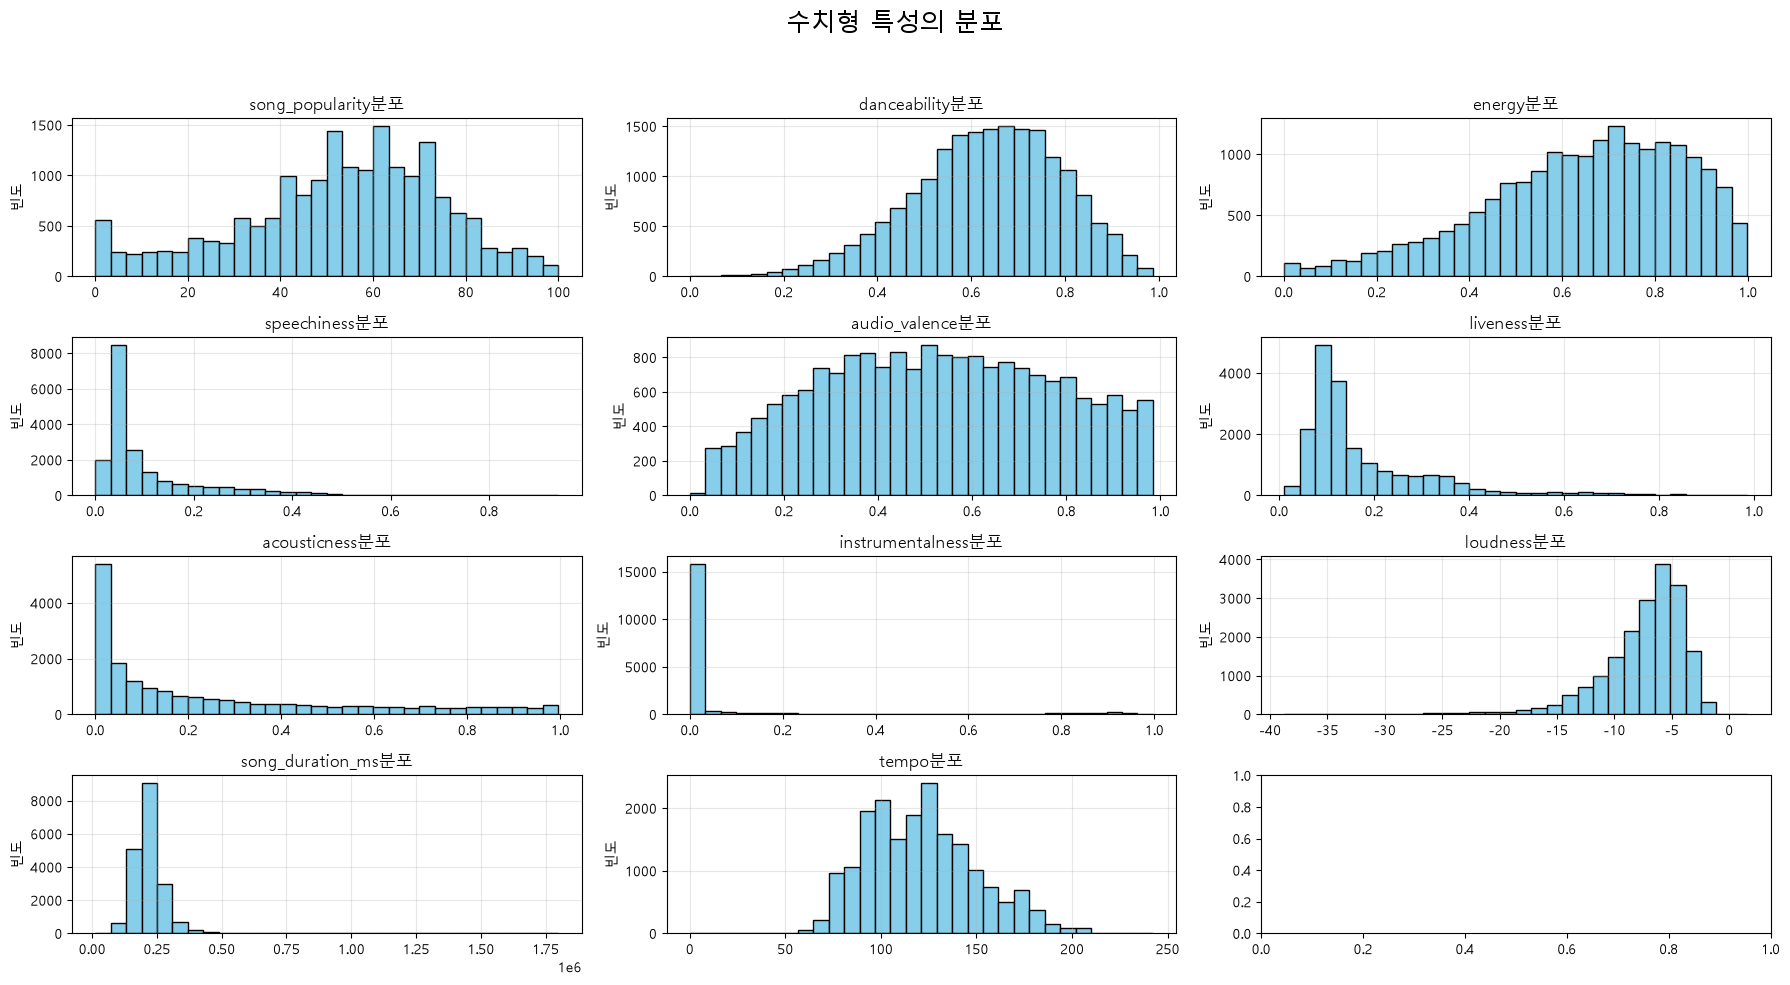

In [49]:
# 수치형 변수의 분포

columns = [target] + nf
fig, axes = plt.subplots(4, 3, figsize = (18,10))

for idx, col in enumerate(columns):
    row = idx // 3  # 행 
    col_idx = idx % 3 # 열
    axes[row][col_idx].hist(df[col], bins = 30, color= 'skyblue', edgecolor = 'black')
    axes[row][col_idx].set_title(f'{col}분포')  # 서브플롯 제목
    axes[row][col_idx].set_ylabel('빈도')       # 서브플롯 y라벨
    axes[row][col_idx].grid(alpha = 0.3)

plt.suptitle('수치형 특성의 분포', fontsize = 18)
plt.tight_layout(rect = [0,0,1,0.95])
plt.show()

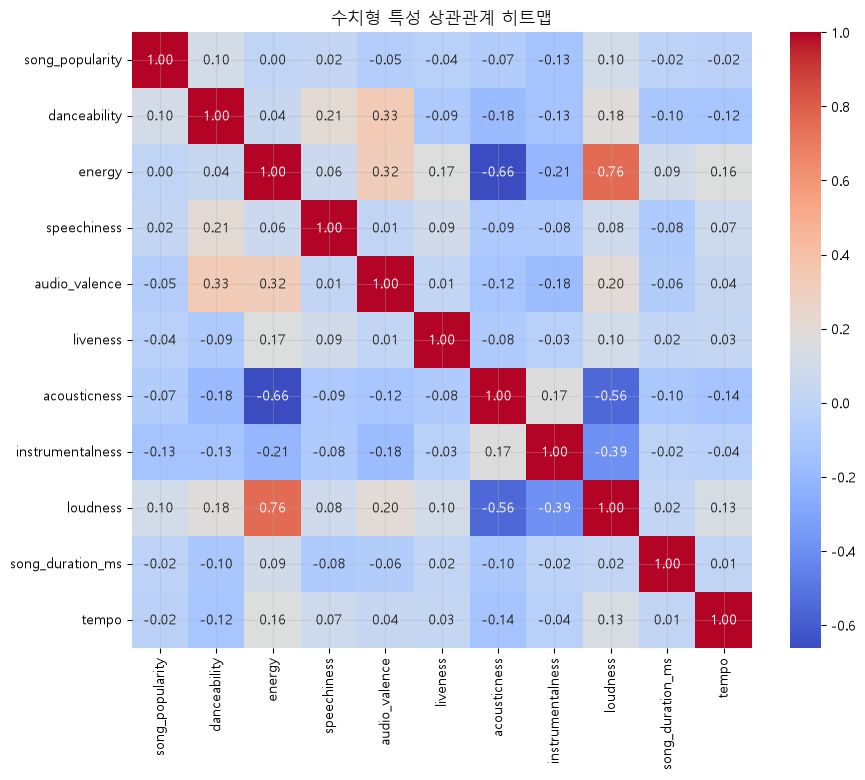

In [50]:
# 수치형 특성 간 상관관계 매트릭스

plt.figure(figsize = (10,8))
corr_matrix = df[[target]+ nf].corr(numeric_only= True)  # 상관계수 계산 (corr : 상관관계함수)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap = 'coolwarm')  # 히트맵으로 시각화 (값 표시, 소수점2자리)
plt.title("수치형 특성 상관관계 히트맵")
plt.grid(alpha = 0.3)
plt.show()

In [51]:
df[nf].columns

Index(['danceability', 'energy', 'speechiness', 'audio_valence', 'liveness',
       'acousticness', 'instrumentalness', 'loudness', 'song_duration_ms',
       'tempo'],
      dtype='str')

In [52]:
from statsmodels.stats.outliers_influence import variance_inflation_factor  #VIF (다중공선성) 지표
from statsmodels.tools import add_constant   # 상수항 추가

checking_columns = ['instrumentalness','loudness','energy','acousticness','audio_valence']
vif_df = df[checking_columns].copy()
vif_df = vif_df.dropna()

vif_data = add_constant(vif_df) # VIF 계산용 상수항 추가

vif_data


,const,instrumentalness,loudness,energy,acousticness,audio_valence
0,1.0,0.000029,-4.095,0.682,0.005520,0.474
1,1.0,0.000000,-6.407,0.853,0.010300,0.370
2,1.0,0.447000,-7.828,0.463,0.008170,0.324
3,1.0,0.003550,-4.938,0.970,0.026400,0.198
4,1.0,0.000000,-5.065,0.766,0.000954,0.574
...,...,...,...,...,...,...
18830,1.0,0.000065,-16.107,0.151,0.893000,0.300
18831,1.0,0.000001,-14.078,0.161,0.765000,0.265
18832,1.0,0.000000,-12.222,0.325,0.847000,0.286
18833,1.0,0.015700,-12.020,0.326,0.945000,0.323


In [53]:
vif = pd.DataFrame()

vif['feature'] = vif_data.columns
# 각 변수별 VIF 계산
vif['VIF'] = [variance_inflation_factor(vif_data.values, i ) for i in range(vif_data.shape[1])]

vif = vif[vif['feature'] != 'const']
vif

,feature,VIF
1,instrumentalness,1.237084
2,loudness,2.751105
3,energy,3.252280
4,acousticness,1.834072
5,audio_valence,1.160981


다중공선성 VIF 지표가 5가 넘으면 높은 다중공선성을 가지므로,   
해당 변수가 다른 변수들과 강한 상관관계를 가짐

C:\Users\UK\AppData\Local\Temp\ipykernel_33556\3795795892.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = "audio_mode", y = "song_popularity", data = df, palette = "Set2")


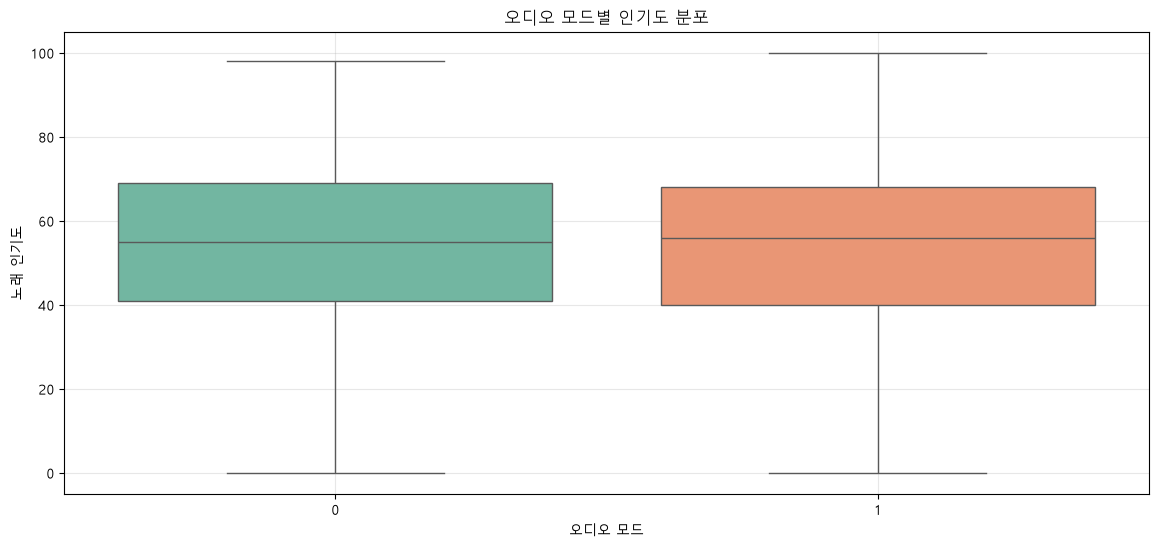

In [54]:
#  target(종속변수)과 다양한 범주형 변수들과의 관계
plt.figure(figsize=(14,6))
sns.boxplot(x = "audio_mode", y = "song_popularity", data = df, palette = "Set2")
plt.title("오디오 모드별 인기도 분포")
plt.xlabel('오디오 모드')
plt.ylabel('노래 인기도')
plt.grid(alpha = 0.3)
plt.show()

C:\Users\UK\AppData\Local\Temp\ipykernel_33556\2571489091.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = "time_signature", y = "song_popularity", data = df, palette = "Set2")


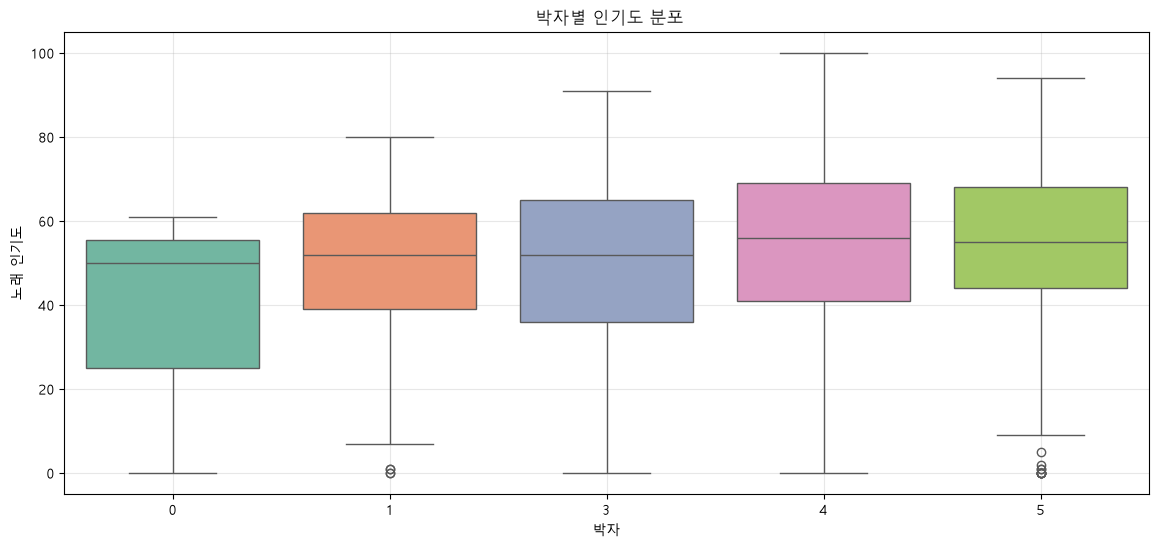

In [55]:
#  target(종속변수)과 다양한 범주형 변수들과의 관계
plt.figure(figsize=(14,6))
sns.boxplot(x = "time_signature", y = "song_popularity", data = df, palette = "Set2")
plt.title(" 박자별 인기도 분포")
plt.xlabel('박자')
plt.ylabel('노래 인기도')
plt.grid(alpha = 0.3)
plt.show()

C:\Users\UK\AppData\Local\Temp\ipykernel_33556\387270499.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = "key", y = "song_popularity", data = df, palette = "Set2")


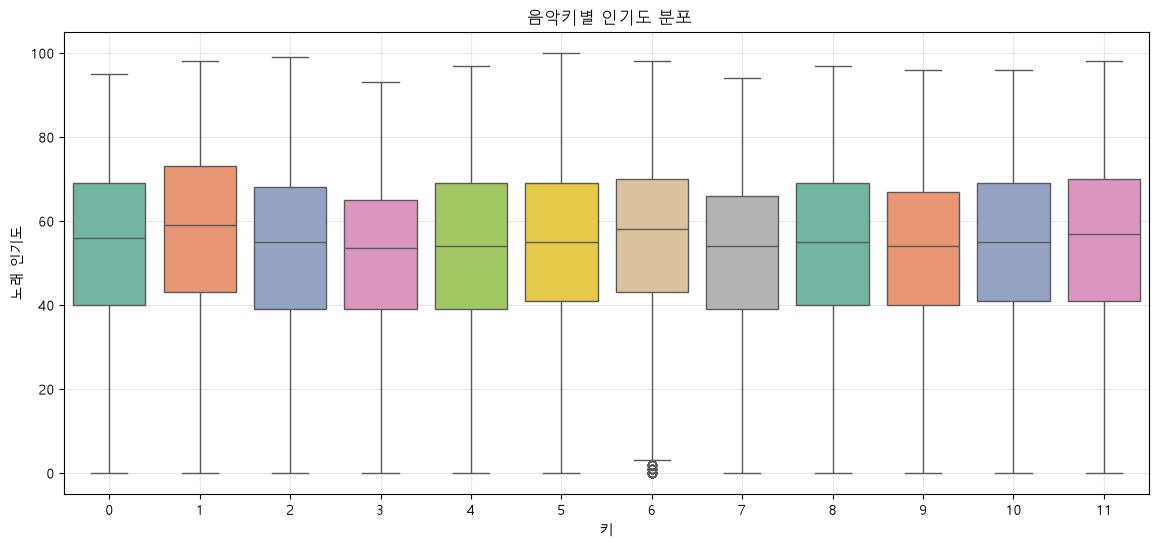

In [56]:
#  target(종속변수)과 다양한 범주형 변수들과의 관계
plt.figure(figsize=(14,6))
sns.boxplot(x = "key", y = "song_popularity", data = df, palette = "Set2")
plt.title(" 음악키별 인기도 분포")
plt.xlabel('키')
plt.ylabel('노래 인기도')
plt.grid(alpha = 0.3)
plt.show()

  범주형 변수들과 인기도의 관계를 봤을때 약간의 이상치는 있지만 구별하기 양호한 데이터로 보임.

### 전처리
- 겵측치 처리
- 이상치 탐색 및 처리
    - 수치형 :  IQR
- 왜도 처리
    - 정규화 진행 => 정규분포에 가깝게
- 범주형 변수
    -문자 -> 숫자로 인코딩

In [57]:
df1 = df.copy() # 데이터 복사


In [58]:
#이상치 
features1 = nf + ['song_popularity']
for i in features1:
    Q1 = df1[i].quantile(0.25)  # 1사분위수
    Q3 = df1[i].quantile(0.75)  # 3사분위수

    IQR = Q3 - Q1
    df1 = df1[df1[i] <= ( Q3 + (1.5 * IQR))]  # 이상치 상한선 초과 데이터 삭제
    df1 = df1[df1[i] >= ( Q1 - (1.5 * IQR))]  # 이상치 하한선 미만 데이터 삭제
    df1 = df1.reset_index(drop = True)

print(f"데이터 정리 전 갯수 : {df.shape[0]}개 , 데이터 정리후 갯수 : {df1.shape[0]}개")


데이터 정리 전 갯수 : 18835개 , 데이터 정리후 갯수 : 11183개


In [59]:
df = df1.copy()

In [60]:
df.columns

Index(['song_popularity', 'song_duration_ms', 'acousticness', 'danceability',
       'energy', 'instrumentalness', 'key', 'liveness', 'loudness',
       'audio_mode', 'speechiness', 'tempo', 'time_signature',
       'audio_valence'],
      dtype='str')

In [61]:
# 정규화 (왜도가 있는 컬럼에는 로그 변환 등 전처리 진행)
skewed_columns = ['speechiness', 'liveness', 'acousticness', 'instrumentalness']


로그 변환은 분포가 한쪽으로 치우친(왜도가 큰) 특성의 정규화를 진행해 모델학습에 도움이 됨.

In [63]:
from copy import deepcopy

df_log = deepcopy(df)

df_log[skewed_columns] = df[skewed_columns].apply(np.log1p)  # log1p : 로그변환 함수 적용

df_log

,song_popularity,song_duration_ms,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,audio_mode,speechiness,tempo,time_signature,audio_valence
0,73,262333,0.005505,0.496,0.682,0.000029,8,0.057231,-4.095,1,0.028976,167.060,4,0.4740
1,66,216933,0.010247,0.542,0.853,0.000000,3,0.102557,-6.407,0,0.048600,105.256,4,0.3700
2,74,216933,0.026058,0.451,0.970,0.003544,0,0.097127,-4.938,1,0.101654,122.444,4,0.1980
3,56,223826,0.000954,0.447,0.766,0.000000,10,0.107059,-5.065,1,0.030820,172.011,4,0.5740
4,80,235893,0.008910,0.316,0.945,0.000002,4,0.333611,-3.169,0,0.116894,189.931,4,0.3200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11178,55,114582,0.640801,0.370,0.136,0.000263,7,0.095219,-13.528,1,0.042389,146.081,4,0.0592
11179,64,216173,0.621651,0.515,0.286,0.000069,5,0.100750,-11.776,1,0.037103,115.076,4,0.2840
11180,62,195106,0.332894,0.644,0.523,0.000000,4,0.088926,-7.660,1,0.037103,95.966,4,0.4450
11181,23,182211,0.613563,0.719,0.325,0.000000,0,0.117783,-12.222,1,0.034884,130.534,4,0.2860


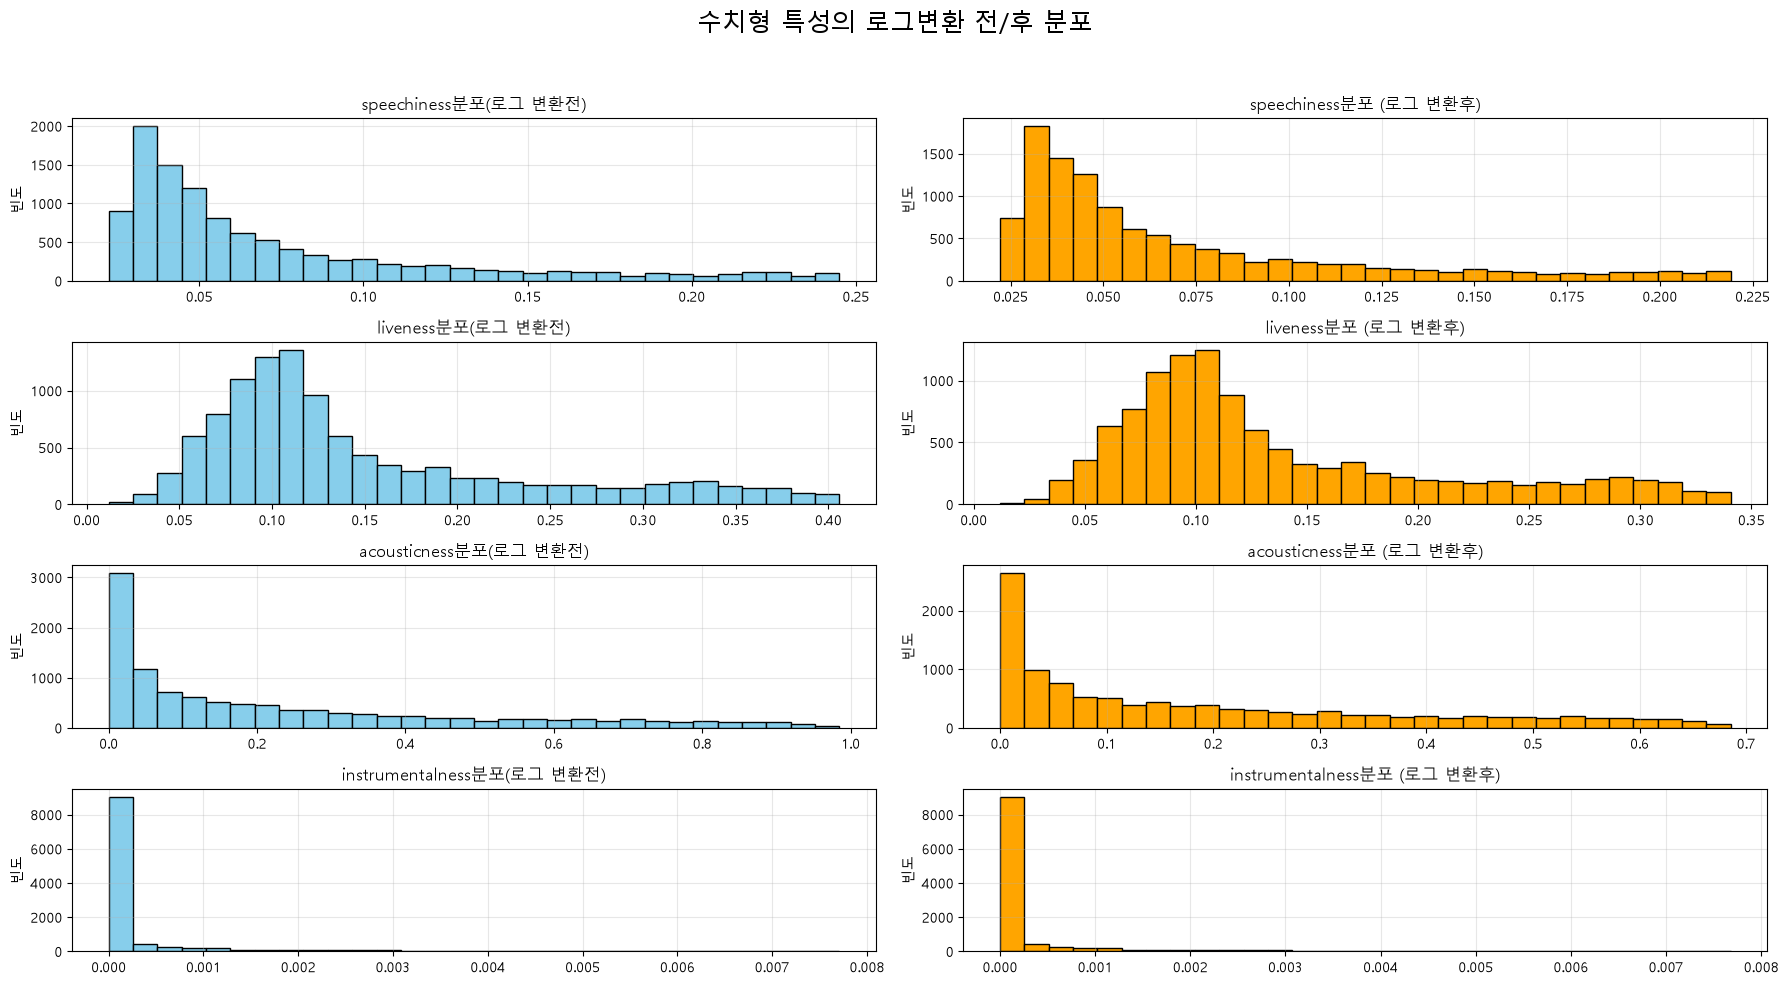

In [64]:
fig, axes = plt.subplots(4,2,figsize = (18,10))

for idx, col in enumerate(skewed_columns):
    row = idx  # 행 
    axes[row][0].hist(df[col], bins = 30, color= 'skyblue', edgecolor = 'black')
    axes[row][0].set_title(f'{col}분포(로그 변환전)')  # 서브플롯 제목
    axes[row][0].set_ylabel('빈도')       # 서브플롯 y라벨
    axes[row][0].grid(alpha = 0.3)

    axes[row][1].hist(df_log[col], bins = 30, color= 'orange', edgecolor = 'black')
    axes[row][1].set_title(f'{col}분포 (로그 변환후)')  # 서브플롯 제목
    axes[row][1].set_ylabel('빈도')       # 서브플롯 y라벨
    axes[row][1].grid(alpha = 0.3)

plt.suptitle('수치형 특성의 로그변환 전/후 분포', fontsize = 18)
plt.tight_layout(rect = [0,0,1,0.95])
plt.show()



skew() : 왜도값 계산.  
값이 0이면 완전 대칭  
0보다 크면 오른쪽으로 긴 분포 (양의 왜도)  
0보다 작으면 왼쪽으로 긴 분포 (음의 왜도)  
|왜도|가 1 이상이면 비대칭하다.  

In [ ]:
# 왜도값 계산 

df[skewed_columns].skew()

speechiness         1.552620
liveness            1.156883
acousticness        1.134955
instrumentalness    3.831057
dtype: float64

In [66]:
df_log[skewed_columns].skew()

speechiness         1.470770
liveness            1.044367
acousticness        0.894389
instrumentalness    3.826448
dtype: float64

In [67]:
df = df_log

In [68]:
df

,song_popularity,song_duration_ms,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,audio_mode,speechiness,tempo,time_signature,audio_valence
0,73,262333,0.005505,0.496,0.682,0.000029,8,0.057231,-4.095,1,0.028976,167.060,4,0.4740
1,66,216933,0.010247,0.542,0.853,0.000000,3,0.102557,-6.407,0,0.048600,105.256,4,0.3700
2,74,216933,0.026058,0.451,0.970,0.003544,0,0.097127,-4.938,1,0.101654,122.444,4,0.1980
3,56,223826,0.000954,0.447,0.766,0.000000,10,0.107059,-5.065,1,0.030820,172.011,4,0.5740
4,80,235893,0.008910,0.316,0.945,0.000002,4,0.333611,-3.169,0,0.116894,189.931,4,0.3200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11178,55,114582,0.640801,0.370,0.136,0.000263,7,0.095219,-13.528,1,0.042389,146.081,4,0.0592
11179,64,216173,0.621651,0.515,0.286,0.000069,5,0.100750,-11.776,1,0.037103,115.076,4,0.2840
11180,62,195106,0.332894,0.644,0.523,0.000000,4,0.088926,-7.660,1,0.037103,95.966,4,0.4450
11181,23,182211,0.613563,0.719,0.325,0.000000,0,0.117783,-12.222,1,0.034884,130.534,4,0.2860


### 선형회귀 모델 학습

In [85]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.model_selection import train_test_split


X = df[features]
y = df[target]

print(X.shape, y.shape)

(11183, 13) (11183,)


In [86]:
# 학습/테스트 데이터 분리 (80%:20%)
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state= 42    
)

print(len(X_train),len(X_test),len(y_train),len(y_test))


8946 2237 8946 2237


In [ ]:
# LinearRegression 모델 학습
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print('학습 완료!')


학습 완료


In [80]:
y_pred_lr = lr_model.predict(X_test)
y_pred_lr

array([53.05591313, 62.67602524, 57.12935895, ..., 53.37069226,
       46.25289331, 52.97383946], shape=(2237,))

In [82]:
y_test[:10]

8778    36
7393    37
7644    59
5106    76
3013    33
9493    80
3790    63
1459    30
8605    67
9441    71
Name: song_popularity, dtype: int64

In [ ]:
print(f"Train MSE : {mean_squared_error(y_train,lr_model.predict(X_train))}")
print(f"Train MAE : {mean_absolute_error(y_train,lr_model.predict(X_train))}")
print(f"Train R2 : {r2_score(y_train,lr_model.predict(X_train))}")
print("---------------------")
print(f"Test MSE : {mean_squared_error(y_test,y_pred_lr)}")
print(f"Test MAE : {mean_absolute_error(y_test,y_pred_lr)}")
print(f"Test R2 : {r2_score(y_test,y_pred_lr)}")

Train MSE : 432.39769620929
Train MAE : 16.519750491755904
Train R2 : 0.05626218577562625
---------------------
Test MSE : 438.9649470861081
Test MAE : 16.69513291502183
Test R2 : 0.05085185287446892


MSE는 제곱오차기 때문에 큰 차이에는 큰 수치로 나타난다.  
MAE는 절대 오차기 때문에 수치 그대로 평균 차이를 볼 수 있다.  
R2는 설명력으로 각 변수들이 인기도에 5%정도만 설명가능하다.  

### 다항회귀 모델 학습

In [91]:
from sklearn.preprocessing import PolynomialFeatures

# 특성을 다항식 특성으로 변환
poly = PolynomialFeatures(degree = 2)
X_train_poly = poly.fit_transform(X_train)  # 학습 데이터는 학습 및 변환
X_test_poly = poly.transform(X_test)        # 검증 데이터는 변환

# 다항식 특성으로 선형 모델 학습
poly_lr_model = LinearRegression()
poly_lr_model.fit(X_train_poly, y_train)

# 학습 데이터와 검증 데이터 모두 예측
y_pred_train = poly_lr_model.predict(X_train_poly)
y_pred_test = poly_lr_model.predict(X_test_poly)

print(f"Train MSE : {mean_squared_error(y_train,y_pred_train)}")
print(f"Train MAE : {mean_absolute_error(y_train,y_pred_train)}")
print(f"Train R2 : {r2_score(y_train,y_pred_train)}")
print("---------------------")
print(f"Test MSE : {mean_squared_error(y_test,y_pred_test)}")
print(f"Test MAE : {mean_absolute_error(y_test,y_pred_test)}")
print(f"Test R2 : {r2_score(y_test,y_pred_test)}")

Train MSE : 435.2559642685377
Train MAE : 16.584584934363832
Train R2 : 0.05002381847082893
---------------------
Test MSE : 441.0898431569061
Test MAE : 16.746773244067054
Test R2 : 0.046257314787042425


이 문제는 선형회귀로는 풀기 어려운 문제다.

In [92]:
from sklearn.ensemble import RandomForestRegressor

# 랜덤 포레스트 모델 생성 및 학습
rf_model = RandomForestRegressor(random_state= 42)
rf_model.fit(X_train,y_train)

# 학습/테스트 데이터로 예측
y_pred_train_rf = rf_model.predict(X_train)
y_pred_rf = rf_model.predict(X_test)

print(f"Train MSE : {mean_squared_error(y_train,y_pred_train_rf)}")
print(f"Train MAE : {mean_absolute_error(y_train,y_pred_train_rf)}")
print(f"Train R2 : {r2_score(y_train,y_pred_train_rf)}")
print("---------------------")
print(f"Test MSE : {mean_squared_error(y_test,y_pred_rf)}")
print(f"Test MAE : {mean_absolute_error(y_test,y_pred_rf)}")
print(f"Test R2 : {r2_score(y_test,y_pred_rf)}")

Train MSE : 43.28802065694041
Train MAE : 4.438311955906715
Train R2 : 0.9055209073613867
---------------------
Test MSE : 274.77396523761075
Test MAE : 11.80355589517433
Test R2 : 0.4058723783873017


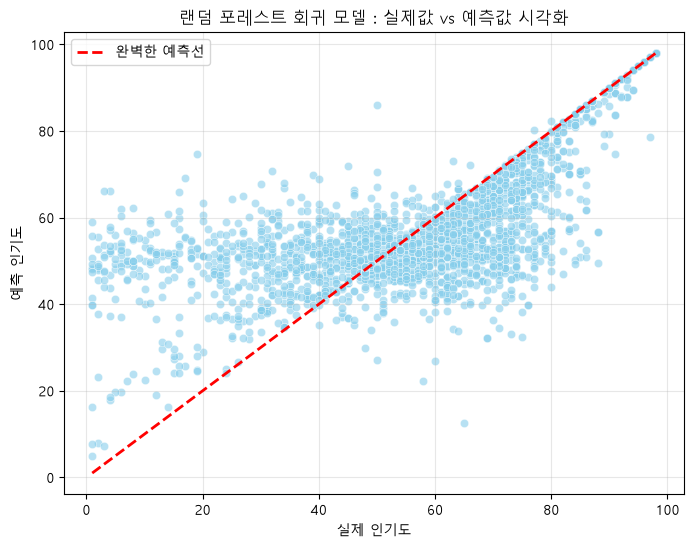

In [93]:
# 실제값 vs 예측값 시각화
plt.figure(figsize=(8,6))
sns.scatterplot(x = y_test,y=y_pred_rf, color = 'skyblue', alpha = 0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 
         'r--', linewidth = 2, label = "완벽한 예측선")
plt.xlabel('실제 인기도')
plt.ylabel("예측 인기도")
plt.title("랜덤 포레스트 회귀 모델 : 실제값 vs 예측값 시각화")
plt.legend()
plt.grid(alpha = 0.3)
plt.show()

모델이 곡의 인기도를 중간 구간(40~60) 구간으로 많이 예측했으나,  
극단적으로 높거나 낮은 점수는 오차가 많이 발생했다.

In [95]:
# 랜덤 포레스트 회귀 모델의 특성 중요도 분석
importances = rf_model.feature_importances_
features = X.columns

feat_df = pd.DataFrame({"특성": features,
                        "중요도" : importances})

feat_df = feat_df.sort_values(by= '중요도', ascending= False)
feat_df

,특성,중요도
7,loudness,0.111606
12,audio_valence,0.106750
2,danceability,0.099819
1,acousticness,0.099417
3,energy,0.098184
6,liveness,0.095433
0,song_duration_ms,0.093416
10,tempo,0.090495
9,speechiness,0.087211
4,instrumentalness,0.060503
